<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/08.8_Tree-Based_Algorithms_and_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 8 - Algoritma Berbasis Pohon dan Metode Ensemble (Tree-Based Algorithms and Ensemble Methods)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 8 Tree-Based Algorithms and Ensemble Methods** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Memuat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya
Kami sekarang dapat membuat Classifier Decision Tree, melatihnya, dan mengevaluasi kinerjanya.

In [2]:
# Buat instance modelnya
clf = DecisionTreeClassifier(random_state=2024)

# Sesuaikan model dengan data latih
clf.fit(X_train, y_train)

# Hasilkan prediksi
y_pred = clf.predict(X_test)

# Evaluasi modelnya
accuracy = accuracy_score(y_test, y_pred)

# Buat laporan klasifikasi
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sesuaikan gaya DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


### Cara kerjanya
Decision Tree bekerja dengan memisahkan kumpulan data berdasarkan nilai fitur. Tujuan dari setiap pemisahan adalah untuk meningkatkan homogenitas, atau “kesamaan,” dalam setiap subkelompok. Keputusan untuk membagi biasanya ditentukan oleh kriteria seperti pengotor Gini (digunakan secara default di scikit-learn) atau entropi.
Kita dapat memvisualisasikan Decision Tree untuk lebih memahami bagaimana pemisahan dilakukan:

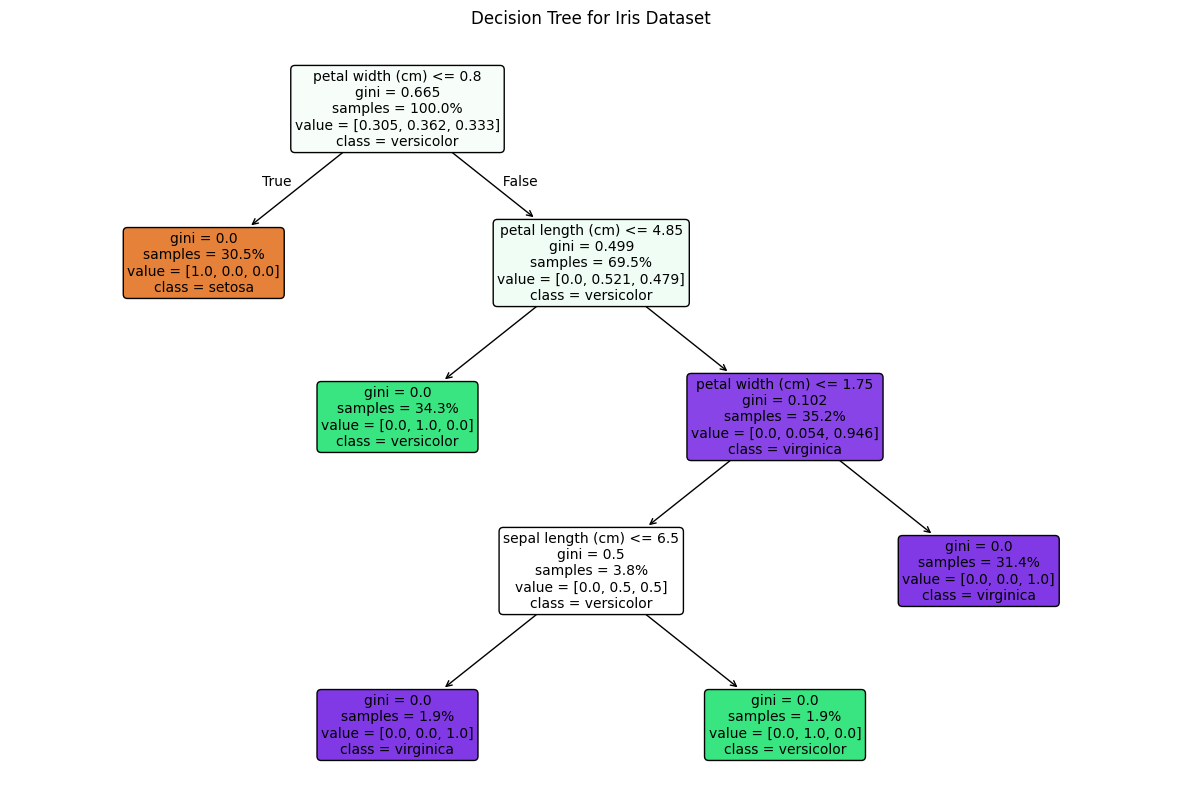

In [3]:
# Muat perpustakaan
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot gambarnya
plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, proportion=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Iris Dataset")
plt.show()

## Random Forest dan Mengantongi
Meskipun pembuatan model Decision Tree tunggal bersifat intuitif, sebagian besar aplikasi dunia nyata hanya akan menggunakannya sebagai bagian dari metode ansambel karena beberapa kekurangannya – terutama dalam Overfitting. Seperti kata pepatah, “dua kepala (atau pohon dalam hal ini) lebih baik dari satu!” 

### Bersiap
Kami akan menggunakan scikit-learn untuk mendemonstrasikan pembuatan Classifier Random Forest.

In [4]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya
Kami sekarang akan membangun, melatih, dan mengevaluasi Classifier Random Forest kami.

In [5]:
# Buat instance modelnya
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)

# Sesuaikan model dengan data latih
rf_clf.fit(X_train, y_train)

# Hasilkan prediksi
y_pred = rf_clf.predict(X_test)

# Evaluasi modelnya
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sesuaikan gaya DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df

,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.833,0.833,0.833,12
2,0.867,0.867,0.867,15
accuracy,0.911,0.911,0.911,1
macro avg,0.900,0.900,0.900,45
weighted avg,0.911,0.911,0.911,45


Random Forest membangun beberapa Decision Tree, masing-masing dilatih berdasarkan sampel kumpulan data yang “di-bootstrap”. Selain itu, pada setiap “pemisahan” dalam sebuah pohon, subkumpulan fitur acak dipertimbangkan, sehingga menimbulkan keragaman lebih lanjut. Pendekatan ini mengurangi varians dan meningkatkan stabilitas model dan generalisasi yang dirancang untuk memungkinkannya bekerja dengan data tak terlihat yang mungkin ditemui dalam aplikasi produksi.

Mari kita visualisasikan pentingnya fitur untuk memahami fitur mana yang berkontribusi paling besar terhadap proses pengambilan keputusan:

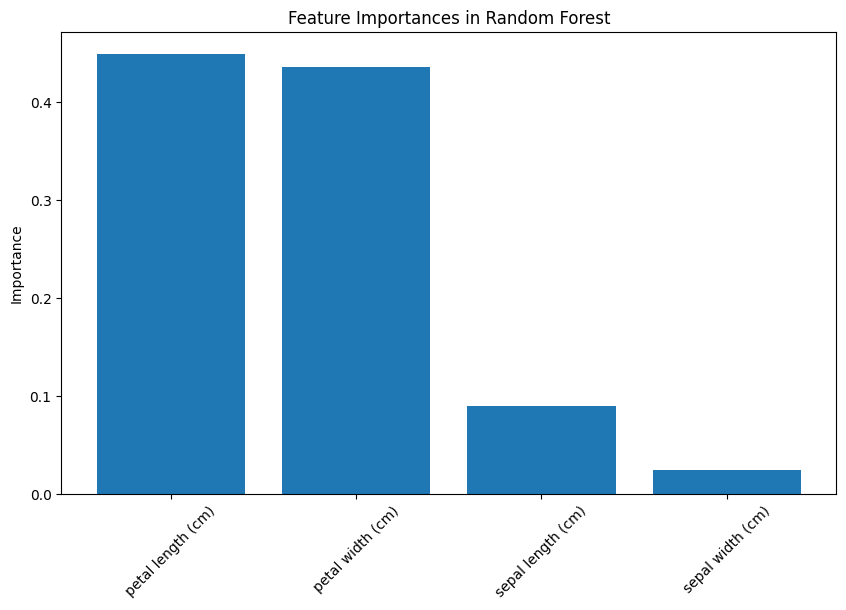

In [6]:
# Muat perpustakaan
import matplotlib.pyplot as plt

# Hitung pentingnya fitur
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot pentingnya fitur
plt.figure(figsize=(10,6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [iris.feature_names[i] for i in indices], rotation=45)
plt.ylabel("Importance")
plt.show()

## Mesin yang Ditingkatkan Gradien
Mesin penguat gradien (GBM) adalah teknik ansambel canggih yang secara berurutan membangun dan menggabungkan model prediksi “lemah”, biasanya Decision Tree, untuk menghasilkan kinerja prediktif yang lebih kuat. Tidak seperti Random Forest, GBM membangun pohon satu per satu, masing-masing bertujuan untuk meminimalkan kesalahan dari model sebelumnya. Cara lain untuk memikirkan hal ini adalah ketika random forest membangun kumpulan Decision Tree secara paralel, GBM membangunnya secara berurutan. Dari sinilah istilah “peningkatan” berasal: kami mencoba “meningkatkan” kinerja prediktif dari setiap pohon yang berurutan. Pendekatan berulang ini dapat meningkatkan akurasi secara signifikan, menjadikan GBM sangat efektif untuk berbagai tugas pembelajaran mesin.

### Bersiap
Kami akan menggunakan scikit-learn untuk mengilustrasikan cara membuat Classifier peningkatan gradien.

In [7]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
	
# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya...
Sekarang, mari buat dan evaluasi model peningkatan gradien kita.

In [8]:
# Buat instance modelnya
gbm_clf = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.2, random_state=2024)

# Sesuaikan model dengan data latih
gbm_clf.fit(X_train, y_train)

# Hasilkan prediksi
y_pred = gbm_clf.predict(X_test)

# Evaluasi modelnya
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Sesuaikan gaya DataFrame
styled_df = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_df


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


### Cara kerjanya...
GBM bekerja dengan membangun model baru secara berulang yang memprediksi sisa (kesalahan) model sebelumnya. Setiap model baru bertujuan untuk meminimalkan residu ini, dan secara bertahap menyempurnakan akurasi prediksi secara keseluruhan.

## Penyetelan Hyperparameter untuk Pohon dan Ansambel
Seperti yang telah kita pelajari dengan baik sekarang, penyesuaian hyperparameter sangat penting untuk mengoptimalkan performa model dan ansambel, termasuk Decision Tree, Random Forest, dan GBM. Dengan memilih hyperparameter secara cermat seperti kedalaman pohon maksimum, jumlah penduga, dan kecepatan pembelajaran, kami dapat meningkatkan performa model secara signifikan dan mencegah Overfitting. Kami akan menggunakan alat yang sama (hanya hyperparameter itu sendiri yang khusus untuk jenis model ini) yang kami gunakan sebelumnya di scikit-learn, seperti Grid Search dan Cross-Validation, untuk menyesuaikan model kami secara sistematis.

### Bersiap
Kami akan mendemonstrasikan penyetelan hyperparameter menggunakan GridSearchCV() scikit-learn dengan Classifier peningkatan gradien.

In [9]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya...
Kami sekarang akan menggunakan Grid Search yang dikombinasikan dengan Cross-Validation untuk menemukan hyperparameter terbaik untuk model peningkatan gradien kami.

In [10]:
# Tentukan kisi hyperparameter
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Siapkan GridSearchCV()
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=2024),
                           param_grid,
                           cv=5,
                           scoring='accuracy')

# Sesuaikan GridSearchCV() dengan data latih
grid_search.fit(X_train, y_train)

# Identifikasi parameter terbaik
print(f'Best Parameters: {grid_search.best_params_}')

# Evaluasi model terbaik
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Hasilkan laporan klasifikasi
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Sesuaikan gaya DataFrame
styled_df = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df


Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


## Cara kerjanya...
Grid Search secara mendalam menguji kombinasi hyperparameter tertentu, menggunakan Cross-Validation untuk mengevaluasi kinerja setiap set. Model yang mencapai skor Cross-Validation terbaik kemudian dipilih sebagai konfigurasi “optimal”. Cross-Validation memastikan estimasi kinerja yang andal dengan mengevaluasi setiap konfigurasi hyperparameter di beberapa subkumpulan dataset yang merupakan cara kami mencoba mensimulasikan nuansa yang mungkin “dilihat” oleh model kami saat bekerja “di alam liar.”

Kami dapat memvisualisasikan hasilnya untuk lebih memahami pengaruh hyperparameter yang berbeda:

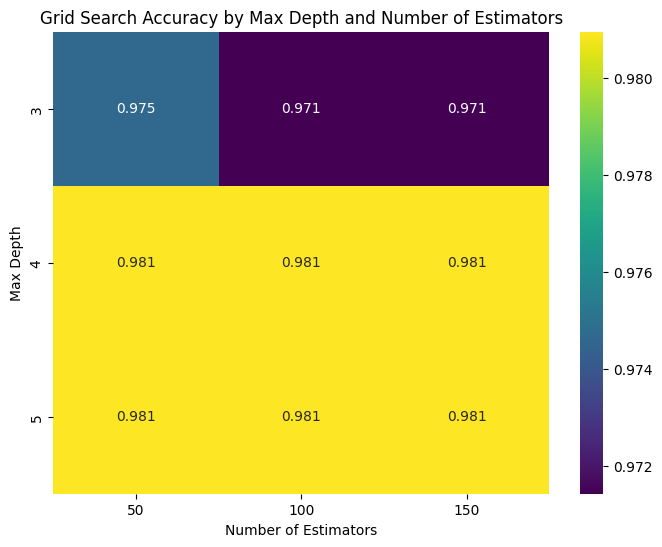

In [11]:
# Muat perpustakaan
import matplotlib.pyplot as plt
import seaborn as sns

# Buat tabel pivot
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(values='mean_test_score', 
                                  index='param_max_depth', 
                                  columns='param_n_estimators')

# Plot peta panasnya
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
plt.title('Grid Search Accuracy by Max Depth and Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()


## Membandingkan Metode Ensemble
Membandingkan metode ansambel membantu kita mengenali kekuatan dan kelemahan relatif dari pendekatan seperti bagging, boosting, dan stacking (yang akan kita lihat di bawah). Setiap metode memiliki karakteristik unik—bagging mengurangi varians, boosting mengurangi bias, dan penumpukan memanfaatkan beberapa algoritme untuk meningkatkan kinerja prediktif. Melalui eksperimen komparatif pada berbagai kumpulan data, kita dapat menentukan strategi ansambel mana yang paling cocok untuk masalah tertentu.

### Bersiap
Kami akan mendemonstrasikan perbandingan metode ansambel yang berbeda menggunakan scikit-learn dengan kumpulan data klasifikasi.

In [12]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya...
Kami akan membangun dan mengevaluasi Classifieran bagging (Random Forest), peningkatan (peningkatan gradien), dan penumpukan.

In [13]:
# Buat instance model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=2024)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    final_estimator=LogisticRegression(),
    cv=5
)
# Sesuaikan modelnya
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

# Hasilkan prediksi
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
stacking_pred = stacking_clf.predict(X_test)

# Evaluasi modelnya
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

# Cetak skor akurasi
print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.2f}')
print(f'Stacking Accuracy: {stacking_accuracy:.2f}')


Random Forest Accuracy: 0.91
Gradient Boosting Accuracy: 0.87
Stacking Accuracy: 0.87


### Cara kerjanya...
Bagging (dengan Random Forest) rata-rata memprediksi dari beberapa pohon yang dibangun di atas kumpulan data bootstrap, sehingga mengurangi varians. Peningkatan (dengan GBM) secara berurutan membangun pohon untuk memperbaiki kesalahan dari model sebelumnya, dengan fokus pada pengurangan bias. Penumpukan, di sisi lain, menggabungkan beberapa model dasar menggunakan “model meta” untuk lebih meningkatkan kinerja prediktif.

Kita dapat memvisualisasikan hasil perbandingan dengan jelas:

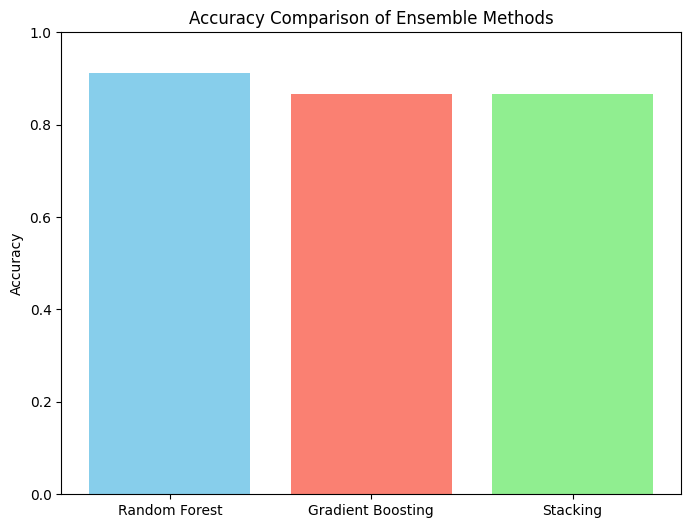

In [14]:
# Muat perpustakaan
import matplotlib.pyplot as plt

# Buat plot batang
methods = ['Random Forest', 'Gradient Boosting', 'Stacking']
accuracies = [rf_accuracy, gb_accuracy, stacking_accuracy]

# Plot plot batang
plt.figure(figsize=(8, 6))
plt.bar(methods, accuracies, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Accuracy Comparison of Ensemble Methods')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()


## Latihan Praktis dengan Model Berbasis Pohon
Di bagian terakhir ini, kita akan melakukan latihan praktis yang melibatkan pembuatan, penyesuaian, dan evaluasi model berbasis pohon dan ansambel pada kumpulan data dunia nyata. Latihan ini dirancang untuk memperkuat konsep yang dipelajari sepanjang bab ini dan menunjukkan cara menerapkan model ini secara efektif dalam skenario pembelajaran mesin yang kompleks. Di akhir bagian ini, kita akan mendapatkan pengalaman langsung yang dapat kita manfaatkan dalam proyek ML kita sendiri.

### Latihan 1: Membangun dan Mengevaluasi Classifier Decision Tree
Dalam latihan ini, kita akan membuat dan mengevaluasi Classifier Decision Tree dasar.

In [15]:
# Memuat perpustakaan
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Muat kumpulan data
wine = load_wine()
X = wine.data
y = wine.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Buat dan latih Classifier
clf = DecisionTreeClassifier(random_state=2024)
clf.fit(X_train, y_train)

# Buatlah prediksi
y_pred = clf.predict(X_test)

# Evaluasi kinerja
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.79      0.95      0.86        20
           2       0.94      0.94      0.94        16

    accuracy                           0.89        54
   macro avg       0.91      0.89      0.89        54
weighted avg       0.90      0.89      0.89        54



### Latihan 2: Penyetelan Hyperparameter dengan Random Forest
Kami akan menyempurnakan Classifier Random Forest menggunakan Grid Search untuk menemukan parameter optimal.

In [16]:
# Memuat perpustakaan
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Muat kumpulan data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Tentukan kisi hyperparameter dan lakukan pencarian kisi
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt', 'log2'] 
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=2024), param_grid, cv=5, error_score='raise')
grid_search.fit(X_train, y_train)

# Evaluasi model terbaik
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Accuracy: {accuracy:.2f}')


Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 150}
Accuracy: 0.95


### Latihan 3: Membandingkan Peningkatan Gradien dan Random Forest
Kami akan membandingkan kinerja peningkatan gradien dan Classifier Random Forest pada kumpulan data klasifikasi.

In [17]:
# Memuat perpustakaan
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Muat kumpulan data
digits = load_digits()
X = digits.data
y = digits.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2024)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Buat prediksi dan evaluasi
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.2f}')


Random Forest Accuracy: 0.97
Gradient Boosting Accuracy: 0.96


### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita mempelajari model berbasis pohon keputusan dan kombinasi ensemble:
* **Decision Tree:** Model intuitif berbentuk struktur keputusan bercabang, sangat mudah dipahami namun rentan overfitting.
* **Bagging & Random Forest:** Melatih banyak Decision Tree secara independen pada subsampel data acak dan fitur acak, lalu menggabungkan hasilnya (voting/rata-rata) untuk mengurangi varians.
* **Gradient Boosting (GBM):** Melatih pohon keputusan secara berurutan (*sequential*), di mana setiap pohon baru fokus memperbaiki kesalahan prediksi dari pohon sebelumnya untuk mengurangi bias.

#### 2. Pandangan ke Depan
Model ensemble berbasis pohon saat ini merupakan algoritma terbaik untuk data tabular terstruktur. Namun, untuk tipe data tidak terstruktur seperti data teks, representasi tabular standar tidak dapat digunakan langsung. Di **Bab 9**, kita akan mempelajari pemrosesan teks (*Text Processing*) untuk mengonversi data teks menjadi representasi numerik.